In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from math import nan
import sys

sys.path.append("/glade/u/home/islas/python/CESM2_with_CMIP7_aer/utils/")
from reading_utils import *
from convert_units import *
from spread_emissions_func import *
from dask_utils import *
from molecular_weights_diameters_densities import *
from CASutils import calendar_utils as cal
from vertical_utils import *

### Here I'm checking each of the corresponding portions of the namelist that they look as expected

In [55]:
### Plotting scripts
def plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minvar,species,titlestr, vert_int=False):
    allcmip6=[]
    for ifile in np.arange(0,len(cmip6),1):
        dat = xr.open_dataset(cmip6[ifile])
        if vert_int == True:
            dat = dat.chunk({'time':12})
            dat_int = vertically_integrate(dat[cmip6var[ifile]]).rename(cmip6var[ifile])
            dat = dat.drop_vars([cmip6var[ifile]])
            dat = xr.merge([dat, dat_int])
        dat_tg = convert_molecules_to_tg_specifywgt(dat, mol_weights[species], cmip6var[ifile])
        allcmip6.append(dat_tg)
    allcmip6 = xr.concat(allcmip6, dim='emiss_type')
    allcmip6 = allcmip6.sum('emiss_type')
    allcmip6_am = cal.calcannualmean(allcmip6)
    
    allcmip7=[]
    for ifile in np.arange(0,len(cmip7),1):
        dat = xr.open_dataset(cmip7[ifile])
        if vert_int == True:
            dat = dat.chunk({'time':12})
            dat_int = vertically_integrate(dat[cmip7var[ifile]]).rename(cmip7var[ifile])
            dat = dat.drop_vars([cmip7var[ifile]])
            dat = xr.merge([dat, dat_int])
        dat_tg = convert_molecules_to_tg_specifywgt(dat, mol_weights[species], cmip7var[ifile])
        allcmip7.append(dat_tg)
    allcmip7 = xr.concat(allcmip7, dim='emiss_type')
    allcmip7 = allcmip7.sum('emiss_type')
    allcmip7_am = cal.calcannualmean(allcmip7)

    allmine=[]
    for ifile in np.arange(0,len(mine),1):
        dat = xr.open_dataset(mine[ifile])
        if vert_int == True:
            dat = dat.chunk({'time':12})
            dat_int = vertically_integrate(dat[minevar[ifile]]).rename(minevar[ifile])
            dat = dat.drop_vars([minevar[ifile]])
            dat = xr.merge([dat, dat_int])
        dat_tg = convert_molecules_to_tg_specifywgt(dat, mol_weights[species], minevar[ifile])
        allmine.append(dat_tg)
    allmine = xr.concat(allmine, dim='emiss_type')
    allmine = allmine.sum('emiss_type')
    allmine_am = cal.calcannualmean(allmine)

    ax = fig.add_axes([0.05,0.7,0.35,0.2])
    ax.set_xlim(1850,2025)
    ax.set_ylabel('Emissions (Tg)')
    ax.set_title(titlestr, fontsize=16)
    ax.plot(allcmip6_am.year, allcmip6_am, color='black', label='CMIP6', linewidth=2)
    ax.plot(allcmip7_am.year, allcmip7_am, color='red', label='CMIP7', linewidth=2)
    ax.plot(allmine_am.year, allmine_am, color='gray', label='Mine', linestyle='dashed', linewidth=2)
    ax.legend()

    return


def plot_number(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minvar,species,titlestr, vert_int = False, chunk=False):
    allcmip6=[]
    for ifile in np.arange(0,len(cmip6),1):
        dat = xr.open_dataset(cmip6[ifile])
        if chunk == True:
            dat = dat.chunk({'time':120})
        dat_tg = get_global_avg_particle(dat, cmip6var[ifile])
        if vert_int == True:
            dat_tg = vertically_integrate(dat_tg)
        allcmip6.append(dat_tg)
    allcmip6 = xr.concat(allcmip6, dim='emiss_type')
    allcmip6 = allcmip6.sum('emiss_type')
    allcmip6_am = cal.calcannualmean(allcmip6)

    allcmip7=[]
    for ifile in np.arange(0,len(cmip7),1):
        dat = xr.open_dataset(cmip7[ifile])
        if chunk == True:
            dat = dat.chunk({'time':120})
        dat_tg = get_global_avg_particle(dat, cmip7var[ifile])
        if vert_int == True:
            dat_tg = vertically_integrate(dat_tg)
        allcmip7.append(dat_tg)
    allcmip7 = xr.concat(allcmip7, dim='emiss_type')
    allcmip7 = allcmip7.sum('emiss_type')
    allcmip7_am = cal.calcannualmean(allcmip7)

    allmine=[]
    for ifile in np.arange(0,len(mine),1):
        dat = xr.open_dataset(mine[ifile])
        if chunk == True:
            dat = dat.chunk({'time':120})
        dat_tg = get_global_avg_particle(dat, minevar[ifile])
        if vert_int == True:
            dat_tg = vertically_integrate(dat_tg)
        allmine.append(dat_tg)
    allmine = xr.concat(allmine, dim='emiss_type')
    allmine = allmine.sum('emiss_type')
    allmine_am = cal.calcannualmean(allmine)

    ax = fig.add_axes([0.05,0.7,0.35,0.2])
    ax.set_xlim(1850,2025)
    ax.set_ylabel('Emissions (particles/s)')
    ax.set_title(titlestr, fontsize=16)
    ax.plot(allcmip6_am.year, allcmip6_am, color='black', label='CMIP6', linewidth=2)
    
    ax.plot(allcmip7_am.year, allcmip7_am, color='red', label='CMIP7', linewidth=2)
    ax.plot(allmine_am.year, allmine_am, color='gray', label='Mine', linestyle='dashed', linewidth=2)
    ax.legend()

    return



bc_a4 anthro sfc

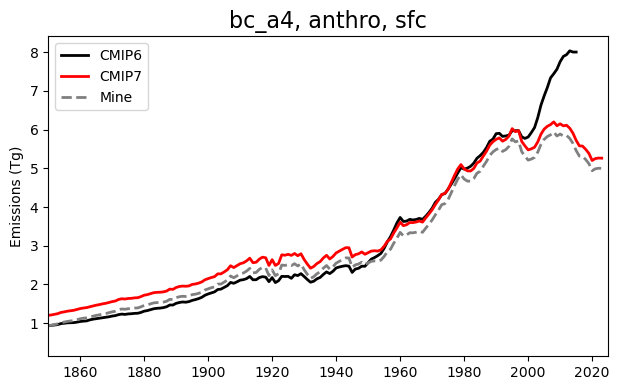

In [3]:
cmip6 =    ["/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_bc_a4_anthro_surface_1750-2015_0.9x1.25_c20170608.nc"]
cmip6var = ["emiss_anthro"]

cmip7 =    ["/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"
              +"bc_a4-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc"]
cmip7var = ["emiss"]

mine =     ["/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/anthro/sfc/CMIP7/bc_a4_anthro_sfc_cmip7_for_cesm2_negspread.nc"]
minevar=   ["emiss"]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'bc_a4','bc_a4, anthro, sfc')

bc_a4 bmb sfc

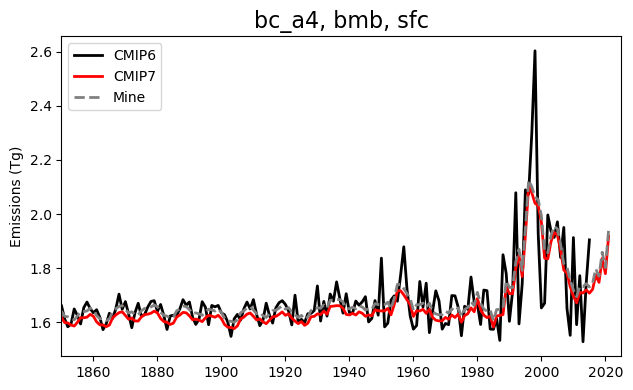

In [5]:
cmip6 = ["/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_bc_a4_bb_surface_1750-2015_0.9x1.25_c20170322.nc"]
cmip6var = [ "emiss_bb" ]

cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/DRES-CMIP-BB4CMIP7-2-0_smoothed_20251102/"
         +"bc_a4_smoothed_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-0_gn_175001-202112_c20251102.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/bmb/sfc/CMIP7/bc_a4_smoothed_bmb_sfc_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'bc_a4','bc_a4, bmb, sfc')

num so4_a1 bmb sfc

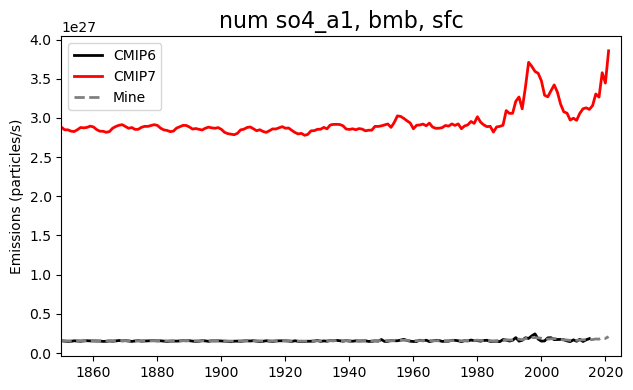

In [11]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_num_so4_a1_bb_surface_1750-2015_0.9x1.25_c20170322.nc" ]
cmip6var = [ "num_so4_a1_bb" ]

cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/DRES-CMIP-BB4CMIP7-2-0_smoothed_20251102/"+
"num_SO4_smoothed_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-0_gn_175001-202112_c20251102.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/number/bmb/sfc/CMIP7/num_so4_a1_bmb_bmb_sfc_SMOOTHED_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_number(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'so4_a1','num so4_a1, bmb, sfc')

Note: the above looks off because of a bug in CMIP7, not a bug in mine

In [ ]:
num so4_a1 (shipping + ag + slv + was) sfc

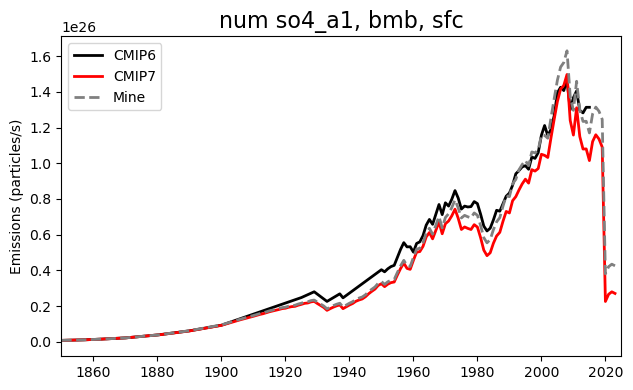

In [7]:
cmip6 = ["/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_num_so4_a1_anthro-ag-ship_surface_1750-2015_0.9x1.25_c20170616.nc",
         "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_num_so4_a1_anthro-ag-ship_surface_1750-2015_0.9x1.25_c20170616.nc" ]
cmip6var=['emiss_shipping', "emiss_ag_sol_was"] 

cmip7 = ["/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+
         "num_so4_a1_ag-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc",
         "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+
         "num_so4_a1_ship_slv-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc"]
cmip7var=['emiss','emiss']

mine = ["/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/number/anthro/sfc/CMIP7/num_so4_a1_ship_anthro_sfc_cmip7_for_cesm2_negspread.nc",
        "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/number/anthro/sfc/CMIP7/num_so4_a1_ag_slv_was_anthro_sfc_cmip7_for_cesm2_negspread.nc"]
minevar=['emiss','emiss']

fig = plt.figure(figsize=(16,16))
plot_number(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'so4_a1','num so4_a1, bmb, sfc')



Note: the above looks off because of the issue of the diameter of solvents + waste

num so4_a2 anthro sfc

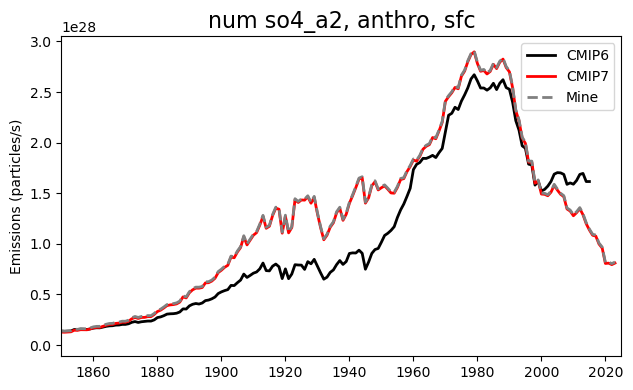

In [9]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_num_so4_a2_anthro-res_surface_1750-2015_0.9x1.25_c20170616.nc" ]
cmip6var = [ "emiss_res_tran" ]

cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+
            "num_so4_a2_res_trs-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/number/anthro/sfc/CMIP7/num_so4_a2_anthro_sfc_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_number(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'so4_a2','num so4_a2, anthro, sfc')

num bc_a4 bmb sfc

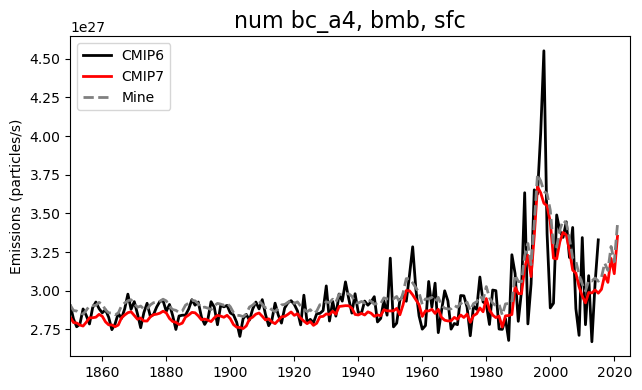

In [12]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_num_bc_a4_bb_surface_1750-2015_0.9x1.25_c20170322.nc" ]
cmip6var = [ "num_bc_a4_bb" ]

cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/DRES-CMIP-BB4CMIP7-2-0_smoothed_20251102/"
             +"num_bc_a4_smoothed_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-0_gn_175001-202112_c20251102.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/number/bmb/sfc/CMIP7/num_bc_a4_bmb_sfc_SMOOTHED_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_number(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'bc_a4','num bc_a4, bmb, sfc')

num bc_a4 anthro sfc

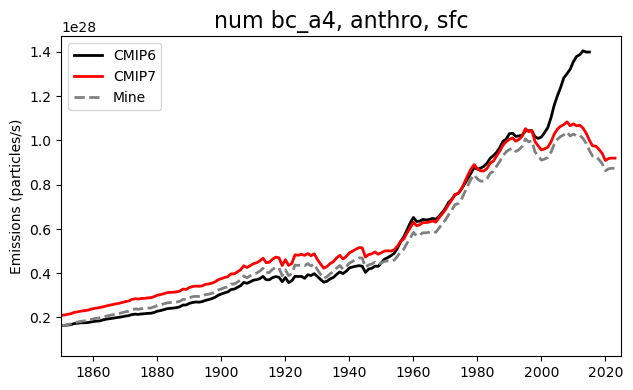

In [14]:
cmip6 = ["/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_num_bc_a4_anthro_surface_1750-2015_0.9x1.25_c20170608.nc"]
cmip6var = [ "num_bc_a4_anthro" ]

cmip7 = ["/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"
          "num_bc_a4-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc"]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/number/anthro/sfc/CMIP7/num_bc_a4_anthro_sfc_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_number(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'bc_a4','num bc_a4, anthro, sfc')

num pom_a4 anthro sfc

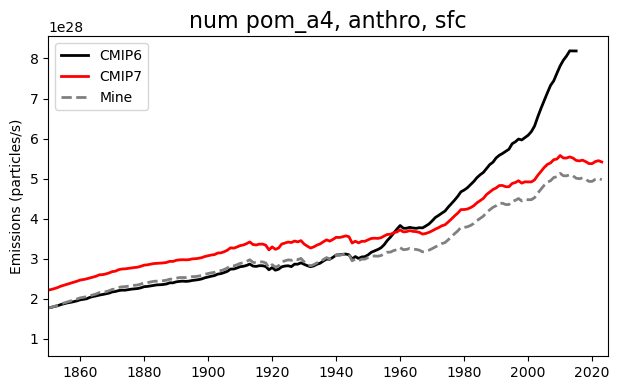

In [15]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_num_pom_a4_anthro_surface_1750-2015_0.9x1.25_c20170608.nc" ]
cmip6var = [ "num_pom_a4_anthro" ]

cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"
                +"num_pom_a4-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/number/anthro/sfc/CMIP7/num_pom_a4_anthro_sfc_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_number(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'pom_a4','num pom_a4, anthro, sfc')

num pom_a4 bmb sfc

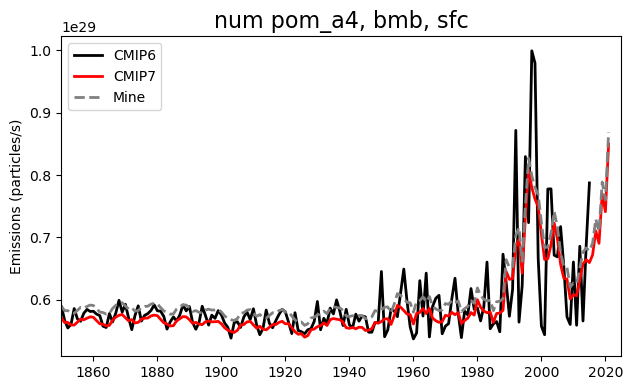

In [16]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_num_pom_a4_bb_surface_1750-2015_0.9x1.25_c20170509.nc" ]
cmip6var = [ "num_pom_a4_bb" ]

cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/DRES-CMIP-BB4CMIP7-2-0_smoothed_20251102/"
                  +"num_pom_a4_smoothed_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-0_gn_175001-202112_c20251102.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/number/bmb/sfc/CMIP7/num_pom_a4_bmb_sfc_SMOOTHED_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_number(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'pom_a4','num pom_a4, bmb, sfc')

pom_a4 anthro sfc

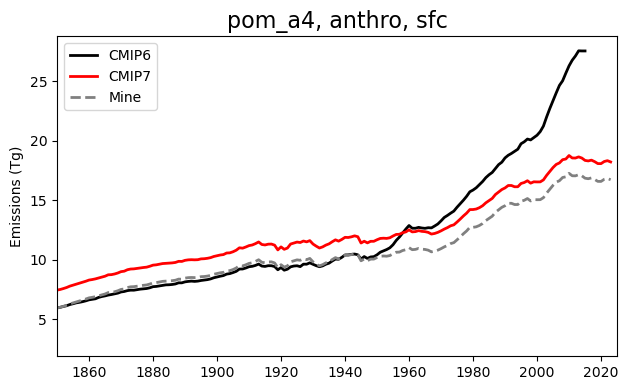

In [17]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_pom_a4_anthro_surface_1750-2015_0.9x1.25_c20170608.nc" ]
cmip6var = [ "emiss_anthro" ]

cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"
                 +"pom_a4-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/anthro/sfc/CMIP7/pom_a4_anthro_sfc_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'pom_a4','pom_a4, anthro, sfc')

pom_a4 bmb sfc

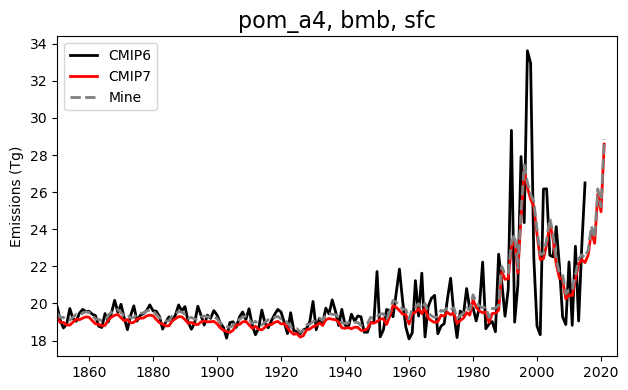

In [20]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_pom_a4_bb_surface_1750-2015_0.9x1.25_c20170322.nc" ]
cmip6var = [ "emiss_bb" ]

cmip7 = [  "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/DRES-CMIP-BB4CMIP7-2-0_smoothed_20251102/"
               +"pom_a4_smoothed_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-0_gn_175001-202112_c20251102.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/bmb/sfc/CMIP7/pom_a4_smoothed_bmb_sfc_cmip7_for_cesm2_negspread.nc" ]
minvar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'pom_a4','pom_a4, bmb, sfc')

SO2 anthro

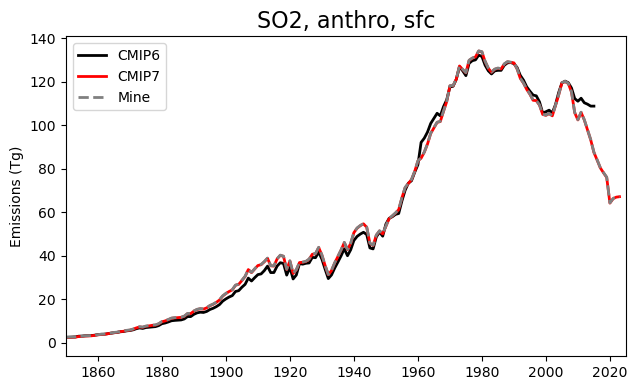

In [23]:
cmip6 = ["/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_SO2_anthro-ag-ship-res_surface_1750-2015_0.9x1.25_c20170616.nc",
         "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_SO2_anthro-ag-ship-res_surface_1750-2015_0.9x1.25_c20170616.nc",
         "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_SO2_anthro-ag-ship-res_surface_1750-2015_0.9x1.25_c20170616.nc",
         "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_SO2_anthro-ene_surface_1750-2015_0.9x1.25_c20170616.nc"]
cmip6var=["emiss_ag_sol_was",
     "emiss_ship",
     "emiss_res_tran",
     "emiss_ene_ind"]

cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+
         "SO2-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/anthro/sfc/CMIP7/SO2_anthro_sfc_cmip7_for_cesm2_negspread.nc" ]
minvar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'SO2','SO2, anthro, sfc')

In [ ]:
SO2 bmb sfc

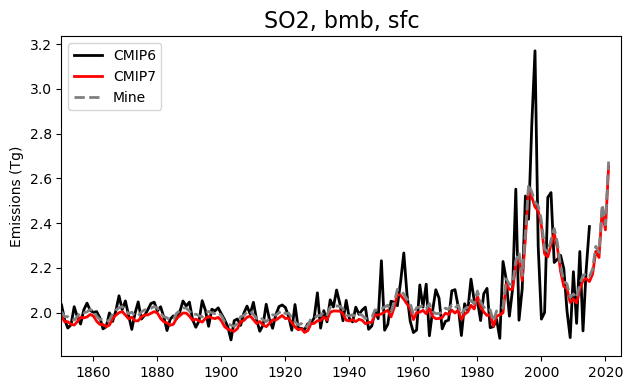

In [24]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_SO2_bb_surface_1750-2015_0.9x1.25_c20170322.nc" ]
cmip6var = [ "emiss_bb" ]
cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/DRES-CMIP-BB4CMIP7-2-0_smoothed_20251102/"+
                  "SO2_smoothed_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-0_gn_175001-202112_c20251102.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/bmb/sfc/CMIP7/SO2_smoothed_bmb_sfc_cmip7_for_cesm2_negspread.nc" ]
minevar =[ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'SO2','SO2, bmb, sfc')

so4_a1 (ag + sol + was + shipping) sfc

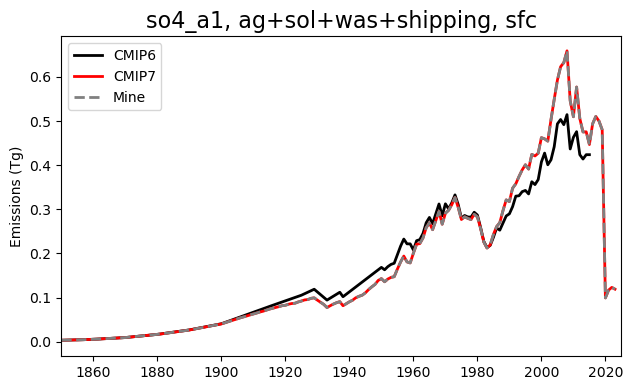

In [28]:
cmip6=["/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_so4_a1_anthro-ag-ship_surface_1750-2015_0.9x1.25_c20170616.nc",
       "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_so4_a1_anthro-ag-ship_surface_1750-2015_0.9x1.25_c20170616.nc"]
cmip6var=["emiss_ag_sol_was",
     "emiss_shipping"]

cmip7=[ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+
       "so4_a1_ag_ship_slv-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
cmip7var=["emiss"]

mine = ["/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/anthro/sfc/CMIP7/so4_a1_ag_slv_was_anthro_sfc_cmip7_for_cesm2_negspread.nc",
        "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/anthro/sfc/CMIP7/so4_a1_ship_anthro_sfc_cmip7_for_cesm2_negspread.nc"]
minevar=["emiss", "emiss"]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'so4_a1_ag','so4_a1, ag+sol+was+shipping, sfc')

so4_a1 bmb sfc

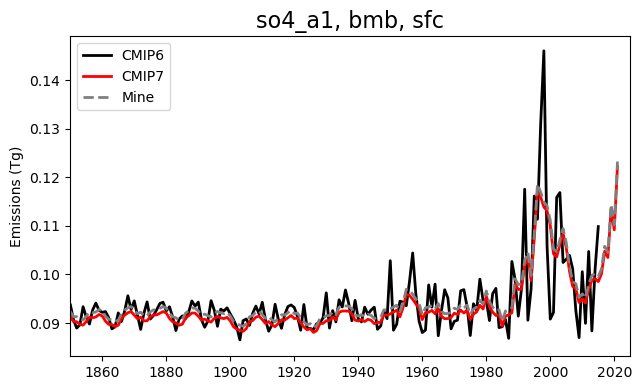

In [29]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_so4_a1_bb_surface_1750-2015_0.9x1.25_c20170322.nc" ]
cmip6var = ["emiss_bb"]

cmip7 = ["/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/DRES-CMIP-BB4CMIP7-2-0_smoothed_20251102/"+
           "SO4_smoothed_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-0_gn_175001-202112_c20251102.nc" ]
cmip7var = ["emiss" ]

mine = ["/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/bmb/sfc/CMIP7/so4_a1_bmb_smoothed_bmb_sfc_cmip7_for_cesm2_negspread.nc"]
minvar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'so4_a1_bmb','so4_a1, bmb, sfc')

so4_a2 anthro sfc

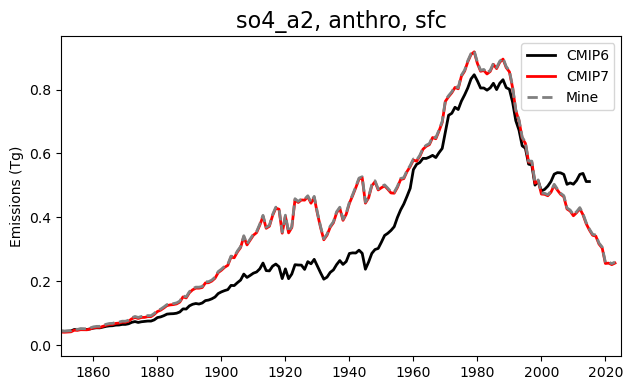

In [31]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_so4_a2_anthro-res_surface_1750-2015_0.9x1.25_c20170616.nc" ]
cmip6var = [ "emiss_res_tran" ]
cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"
               +"so4_a2_res_trs-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
cmip7var = [ "emiss" ]
mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/anthro/sfc/CMIP7/so4_a2_anthro_sfc_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'so4_a2','so4_a2, anthro, sfc')

SOAG anthro sfc

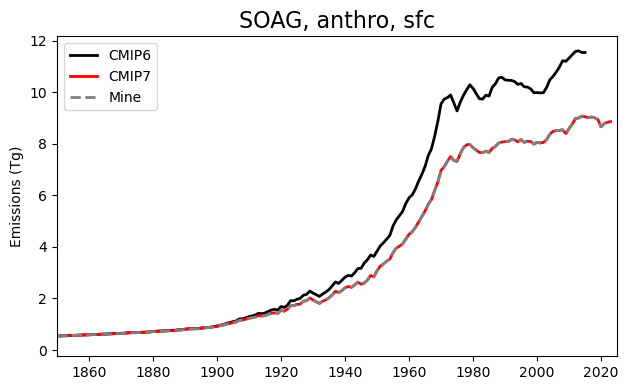

In [32]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_SOAGx1.5_anthro_surface_1750-2015_0.9x1.25_c20170608.nc" ]
cmip6var = [ "emiss_anthro" ]

#!!! Repeating min here because I don't have CMIP7 SOAG files
cmip7 = [  "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/anthro/sfc/CMIP7/SOAG_anthro_sfc_cmip7_for_cesm2_negspread.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/anthro/sfc/CMIP7/SOAG_anthro_sfc_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'SOAG','SOAG, anthro, sfc')

SOAG bmb sfc

Note:
I had used the following file from which to compute the anomalies\
emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_smoothed_SOAGx1.5_bb_surface_mol_175001-210101_0.9x1.25_c20201016.nc

This does not have the same emissions as the default CMIP6 piControl\
emissions-cmip6_SOAGx1.5_bb_surface_1750-2015_0.9x1.25_c20170322.nc

It looks like the one I used is approximately 1.5 times the default piControl.  I'm going to assume that the older file was not multiplied by 1.5 and the newer file is.

I did check my SOAG emissions compared to a file from Ben's and I do indeed need to multiply by 1.5 to reproduce that.

I'm going to accept that my 1850 SOAG bmb emissions might not be exactly the same as in the CMIP6 piControl because it seems preferable to use what was used in the large ensemble

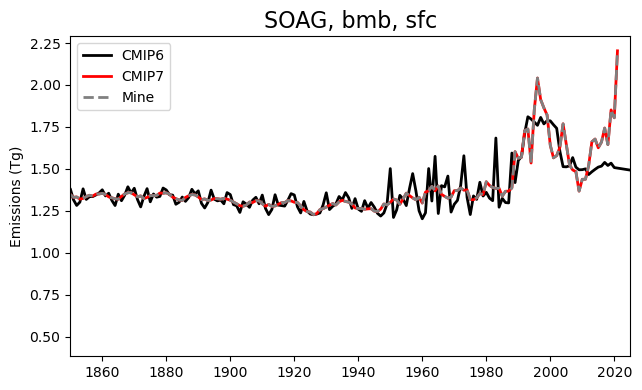

In [41]:
#cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_SOAGx1.5_bb_surface_1750-2015_0.9x1.25_c20170322.nc" ]
cmip6 = [ "/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370-BB_smoothed/"+
          "emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_smoothed_SOAGx1.5_bb_surface_mol_175001-210101_0.9x1.25_c20201016.nc" ]
cmip6var = [ "emiss_bb" ]

cmip7 = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/bmb/sfc/CMIP7/SOAG_smoothed_bmb_sfc_cmip7_for_cesm2_negspread.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/bmb/sfc/CMIP7/SOAG_smoothed_bmb_sfc_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'SOAG','SOAG, bmb, sfc')


### Elevated Emissions

In [3]:
cluster = get_dask_cluster(4)

/glade/work/islas/conda-envs/islaenv26/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/islas/conda-envs/islaenv26/lib/python3.10/site-packages/dask_jobqueue/pbs.py:82: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/islas/conda-envs/islaenv26/lib/python3.1

In [6]:
cluster

PBSCluster(3df2d7f2, 'tcp://10.18.206.83:40555', workers=3, threads=3, memory=83.82 GiB)

num so4_a1 anthro

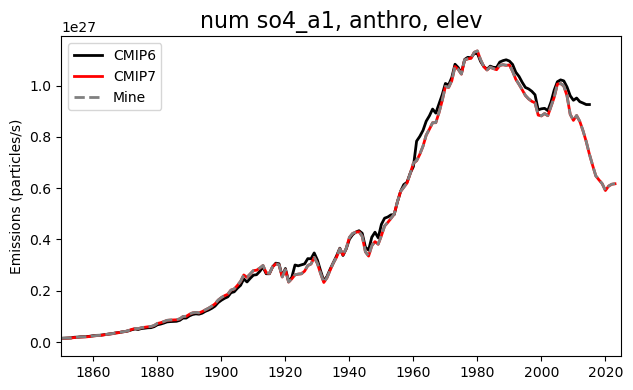

In [57]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_num_so4_a1_anthro-ene_vertical_1750-2015_0.9x1.25_c20170616.nc" ]
cmip6var = [ "emiss_ene_ind" ]

cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+
         "num_so4_a1_ene_vertical-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/number/anthro/elev/CMIP7/num_so4_a1_ene_ind_anthro_elev_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_number(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'so4_a1','num so4_a1, anthro, elev', vert_int = True)

so4_a1 anthro

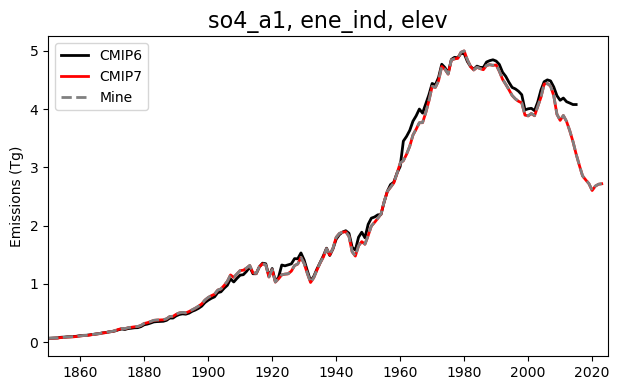

In [56]:
cmip6 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_so4_a1_anthro-ene_vertical_1750-2015_0.9x1.25_c20170616.nc" ]
cmip6var =[ "emiss_ene_ind" ]
cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+ 
         "so4_a1_ene_vertical-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
cmip7var = [ "emiss" ]
mine = [ "/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/anthro/elev/CMIP7/so4_a1_ene_ind_anthro_elev_cmip7_for_cesm2_negspread.nc" ]
minevar = [ "emiss" ]

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'so4_a1_ene_ind','so4_a1, ene_ind, elev', vert_int=True)

bc_a4_planes

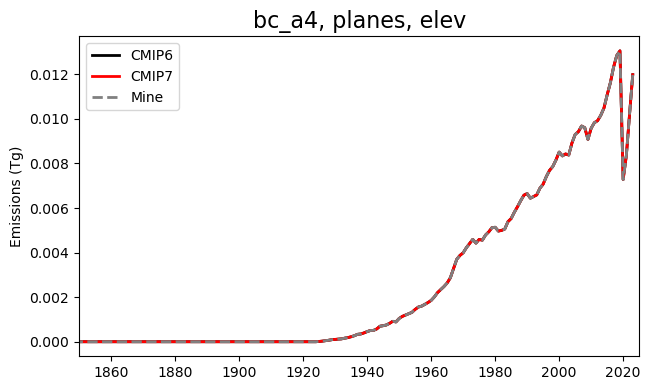

In [59]:
cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+
         "bc_a4-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+
        "bc_a4-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
minevar = [ 'emiss']

# Don't have this for CMIP6 so just putting cmip7 in its place
cmip6 = cmip7
cmip6var = cmip7var

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'bc_a4','bc_a4, planes, elev', vert_int=True)

num_a4_planes

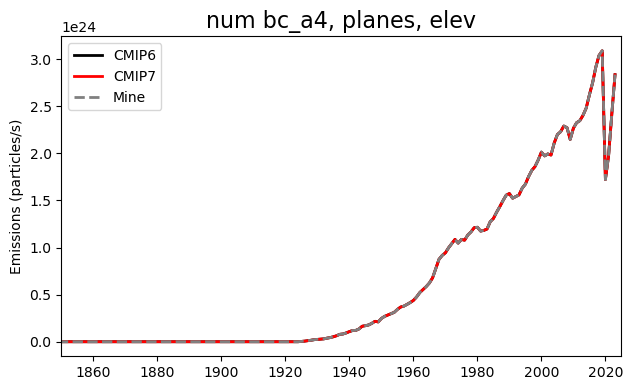

In [60]:
cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+ 
         "num_bc_a4-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
cmip7var = [ "emiss" ]

mine = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+
        "num_bc_a4-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
minevar = [ "emiss" ]

# Don't have this for CMIP6 so just putting cmip7 in its place
cmip6 = cmip7
cmip6var = cmip7var

fig = plt.figure(figsize=(16,16))
plot_number(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'so4_a1','num bc_a4, planes, elev', vert_int = True)


SO2_planes 

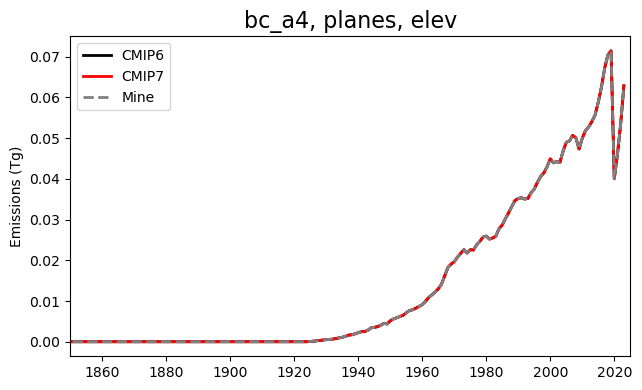

In [62]:
cmip7 = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+
          "SO2-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
cmip7var = ["emiss"]

mine = [ "/glade/campaign/cesm/cesmdata/inputdata/atm/cam/chem/emis/cmip7/ne30/CEDS-CMIP-2025-04-18_20251030/"+
        "SO2-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc" ]
minvar = [ "emiss" ]

# Don't have this for CMIP6 so just putting cmip7 in its place
cmip6 = cmip7
cmip6var = cmip7var

fig = plt.figure(figsize=(16,16))
plot_emiss_molecules(fig, cmip6,cmip6var,cmip7,cmip7var,mine,minevar,'bc_a4','bc_a4, planes, elev', vert_int=True)